In [1]:
from quantum_function import *

# Entanglement of a pair of quantum emitters via continuous fluorescence measurements: a tutorial

### SME - ENTANGLEMENT BY JOINT HOMODYNE DETECTION OF FLUORESCENCE, Chap.5

### Two atoms that emit photons by spontaneous decay, these photons are collected and let them pass through a beam splitter, then we perform homodyne detection

The system is described by Hamiltonian:
$H_{tot} = H_{atom_1} + H_{atom_2} + H_{env} + H_{int}$

where $(\hbar=1)$ $H_{atom_j} = \dfrac{\omega}{2} \cdot \hat{\sigma_{z}}^{j}$

and $H_{int} = \gamma \sum_{j=1}^{2} \left( \hat{a}_{j} \hat{\sigma}_{+}^{j} +\hat{a}^{\dagger}_{j} \hat{\sigma}_{-}^{j}      \right)$

The associated stochastic master equation when performing joint homodyne detection is:

$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho$

## Joint heterodyne
$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho = -i \left[ H, \varrho\right] + \gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}+\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho+\gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}-\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho$

In [ ]:

GAMMA = 1              # Atom decay rate
T_1 = 1 / GAMMA  # time constant for the decay
times = np.arange(0, 5*T_1, 0.001*T_1) # time vector

my_theta = [0, 1 / (3), 1 /2] # angles for the homodyne detection
ntraj = 10

mean_conc_ee_solutions_jhom = []

for theta in my_theta:
    sc_ops = [
    np.sqrt(GAMMA / 2) * (sigma_minus_1 + sigma_minus_2),
    np.exp(1j * np.pi * theta) * np.sqrt(GAMMA / 2) * (sigma_minus_1 - sigma_minus_2)
    ]
   
    my_exp = ssesolve(
        H_free, ee, times,
        sc_ops=sc_ops,
        ntraj=ntraj,
        heterodyne = True,
        e_ops=[concurrence_for_solver_general],
        options={"dt": 0.001, "num_cpus": 4, "map" : "parallel"},
    )

    mean_conc = my_exp.expect[0]

    mean_conc_ee_solutions_jhom.append(mean_conc)

10.0%. Run time:  50.11s. Est. time left: 00:00:07:31
20.0%. Run time:  93.78s. Est. time left: 00:00:06:15
30.0%. Run time: 140.00s. Est. time left: 00:00:05:26
40.0%. Run time: 203.20s. Est. time left: 00:00:05:04
50.0%. Run time: 275.53s. Est. time left: 00:00:04:35
60.0%. Run time: 343.43s. Est. time left: 00:00:03:48
70.0%. Run time: 413.86s. Est. time left: 00:00:02:57
80.0%. Run time: 484.92s. Est. time left: 00:00:02:01
90.0%. Run time: 556.03s. Est. time left: 00:00:01:01
100.0%. Run time: 626.16s. Est. time left: 00:00:00:00
Total run time: 626.81s
10.0%. Run time:  77.18s. Est. time left: 00:00:11:34
20.0%. Run time: 147.22s. Est. time left: 00:00:09:48
30.0%. Run time: 217.77s. Est. time left: 00:00:08:28
40.0%. Run time: 286.66s. Est. time left: 00:00:07:09
50.0%. Run time: 355.84s. Est. time left: 00:00:05:55
60.0%. Run time: 424.03s. Est. time left: 00:00:04:42
70.0%. Run time: 494.35s. Est. time left: 00:00:03:31
80.0%. Run time: 592.74s. Est. time left: 00:00:02:28
90.

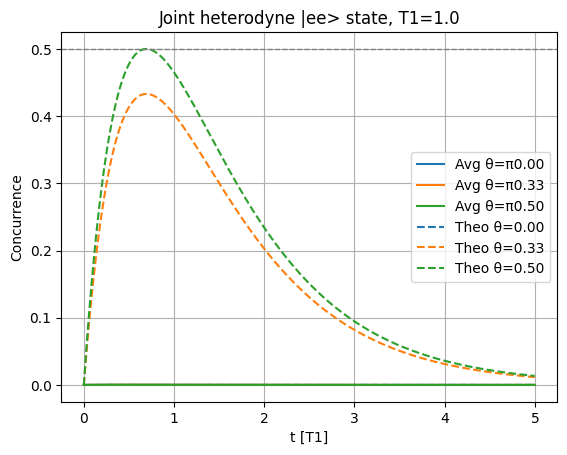

In [ ]:
line_theta = []
line_theo = []

for i, theta in enumerate(my_theta):
    # plottiamo la curva per il theta i-esimo
    line_theta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom[i], label=f"Avg θ=π{(theta):.2f}")
    line_theta.append(line_theta_temp)

    line_theor_temp, = plt.plot(times, theo_concurrence(times, GAMMA)*np.sin(np.pi*theta), color=line_theta_temp.get_color(), linestyle ='--', label=f"Theo θ={theta:.2f}")
    line_theo.append(line_theor_temp)

#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Joint heterodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_theta + line_theo)
plt.show()

In [ ]:
from qutip import parallel_map

def test_func(x):
    return x**2

if __name__ == "__main__":
    out = parallel_map(test_func, [1,2,3], task_kwargs={}, map_kw={'num_cpus': 1})
    print(out)


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.